<div style="background-color:#0a0a0a;color:#00ff41;padding:10px 15px;font-family:'Courier New',Courier,monospace;border-left:5px solid #00ff41;border-bottom:1px solid #00ff41;box-shadow:inset 0 0 5px #000000;text-align:center;"><h1 style="margin:0;text-transform:uppercase;">&#9608; Práctica 02 — Transformación de Variables: Categóricas y Numéricas &#9608;</h1></div>

**Institución:** Universidad Técnica  
**Asignatura:** Inteligencia Artificial  
**Estudiante:** Alex Guaman  
**Fecha:** 2026-04-25  

---

Esta práctica tiene como objetivo aplicar técnicas de **transformación de variables** sobre el dataset `DATOS-IA.xlsx`, siguiendo el flujo de preparación de datos propio de un proyecto de Machine Learning.

Las **actividades en clase** son:
1. Realizar tabla de diseño de transformaciones
2. Ejecutar transformaciones categóricas
3. Ejecutar transformaciones numéricas
4. Calcular la media y la desviación estándar de la variable `edad` una vez estandarizada

**Estructura del notebook:**
- [Fundamentos](#fundamentos)
- [Fase 1: Carga del dataset](#carga)
- [Fase 2: Tabla de diseño](#tabla)
- [Fase 3: Diseño del Pipeline](#pipeline)
- [Fase 4: Ejecución de transformaciones](#ejecucion)
- [Fase 5: Estadísticos post-transformación](#estadisticos)
- [Conclusiones](#conclusiones)

<div id="fundamentos" style="background-color:#0a0a0a;color:#00ff41;padding:10px 15px;font-family:'Courier New',Courier,monospace;border-left:5px solid #00ff41;border-bottom:1px solid #00ff41;box-shadow:inset 0 0 5px #000000;"><h2 style="margin:0;text-transform:uppercase;">&gt; Fundamentos: Tipos de Variables y Transformación_ &#9608;</h2></div>

**¿Por qué transformamos variables?**  
Los algoritmos de Machine Learning requieren que los datos estén en formato numérico y, preferiblemente, en escalas comparables. Sin transformación, variables con diferentes escalas pueden sesgar los resultados del modelo.

---

**1. Variables Categóricas** — Indican categorías o tipos, no cantidades.

**1.1 Nominales:** No existe orden entre las categorías.  
Ejemplo: `sexo` (F, M), `país` (Brasil, España, Chile, Ecuador)  
→ Transformación: **One-Hot Encoding** (`OneHotEncoder`)

```
país:   Brasil=[1,0,0,0]  España=[0,1,0,0]  Chile=[0,0,1,0]  Ecuador=[0,0,0,1]
```

**1.2 Ordinales:** Existe un orden lógico entre las categorías.  
Ejemplo: `nivelSatisfaccion` (no me gusta < neutral < me gusta)  
→ Transformación: **Ordinal Encoding** (`OrdinalEncoder`)

```
no me gusta=0    neutral=1    me gusta=2
```

---

**2. Variables Numéricas** — Valores cuantitativos medibles.

**2.1 Continuas:** Rango continuo de valores. Ejemplo: `edad`  
**2.2 Discretas:** Valores enteros específicos. Ejemplo: número de hijos

**Tipos de transformación numérica:**
- **Normalización Min-Max:** lleva los valores al rango [0, 1]
- **Estandarización Z-score:** media=0, desviación estándar=1 ← *usaremos esta*

<div style="background-color:#0a0a0a;color:#00ff41;padding:10px 15px;font-family:'Courier New',Courier,monospace;border-left:5px solid #00ff41;border-bottom:1px solid #00ff41;box-shadow:inset 0 0 5px #000000;"><h3 style="margin:0;text-transform:uppercase;">&gt; Fórmula — Estandarización Z-Score_ &#9608;</h3></div>

$$v' = \frac{v - \overline{x}}{\sigma}$$

Donde $\overline{x}$ es la media y $\sigma$ es la desviación estándar de la variable original.

<div id="carga" style="background-color:#0a0a0a;color:#00ff41;padding:10px 15px;font-family:'Courier New',Courier,monospace;border-left:5px solid #00ff41;border-bottom:1px solid #00ff41;box-shadow:inset 0 0 5px #000000;"><h2 style="margin:0;text-transform:uppercase;">&gt; Fase 1: Importación de Librerías y Carga del Dataset_ &#9608;</h2></div>

<div style="background-color:#0a0a0a;color:#00ff41;padding:10px 15px;font-family:'Courier New',Courier,monospace;border-left:5px solid #00ff41;border-bottom:1px solid #00ff41;box-shadow:inset 0 0 5px #000000;"><h3 style="margin:0;text-transform:uppercase;">&gt; Importación de Librerías_ &#9608;</h3></div>

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import copy
import warnings
warnings.filterwarnings('ignore')

# Librerías de transformación (scikit-learn)
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import set_config

# Visualización del pipeline como diagrama interactivo
set_config(display='diagram')
print('✔ Módulos importados correctamente')

✔ Módulos importados correctamente


<div style="background-color:#0a0a0a;color:#00ff41;padding:10px 15px;font-family:'Courier New',Courier,monospace;border-left:5px solid #00ff41;border-bottom:1px solid #00ff41;box-shadow:inset 0 0 5px #000000;"><h3 style="margin:0;text-transform:uppercase;">&gt; Carga del Dataset_ &#9608;</h3></div>

**Nombre del dataset:** DATOS-IA.xlsx  
**Fuente:** Archivo local del curso de Inteligencia Artificial  
**Descripción:** Dataset que contiene información de personas con variables de distinto tipo.

| Variable | Tipo | Valores posibles |
|---|---|---|
| `sexo` | Categórica Nominal | F, M |
| `edad` | Numérica Continua | Valores enteros (años) |
| `país` | Categórica Nominal | Brasil, España, Chile, Ecuador |
| `nivelSatisfaccion` | Categórica Ordinal | no me gusta, neutral, me gusta |

In [12]:
# Carga del dataset (la fila 0 es un título, usamos header=1)
dfOriginal = pd.read_excel('../data/DATOS-IA.xlsx', header=1)

print(f'✔ Dataset cargado: {dfOriginal.shape[0]} filas × {dfOriginal.shape[1]} columnas')
print()
print('Tipos de datos por variable:')
print(dfOriginal.dtypes)
print()
dfOriginal

✔ Dataset cargado: 6 filas × 4 columnas

Tipos de datos por variable:
sexo                   str
edad                 int64
país                   str
nivelSatisfaccion      str
dtype: object



,sexo,edad,país,nivelSatisfaccion
0,F,65,Brasil,me gusta
1,M,26,España,no me gusta
2,F,21,Chile,neutral
3,M,12,Ecuador,no me gusta
4,F,32,España,me gusta
5,M,9,Ecuador,no me gusta


In [13]:
# Verificación de valores únicos por variable categórica
print('═'*45)
print('  VALORES ÚNICOS POR VARIABLE')
print('═'*45)
for col in dfOriginal.columns:
    vals = dfOriginal[col].unique().tolist()
    print(f'  {col}: {vals}')
print('═'*45)

═════════════════════════════════════════════
  VALORES ÚNICOS POR VARIABLE
═════════════════════════════════════════════
  sexo: ['F', 'M']
  edad: [65, 26, 21, 12, 32, 9]
  país: ['Brasil', 'España', 'Chile', 'Ecuador']
  nivelSatisfaccion: ['me gusta', 'no me gusta', 'neutral']
═════════════════════════════════════════════


<div id="tabla" style="background-color:#0a0a0a;color:#00ff41;padding:10px 15px;font-family:'Courier New',Courier,monospace;border-left:5px solid #00ff41;border-bottom:1px solid #00ff41;box-shadow:inset 0 0 5px #000000;"><h2 style="margin:0;text-transform:uppercase;">&gt; Fase 2: Actividad 1 — Tabla de Diseño de Transformaciones_ &#9608;</h2></div>

<div style="background-color:#0a0a0a;color:#00ff41;padding:10px 15px;font-family:'Courier New',Courier,monospace;border-left:5px solid #00ff41;border-bottom:1px solid #00ff41;box-shadow:inset 0 0 5px #000000;"><h3 style="margin:0;text-transform:uppercase;">&gt; Análisis y Clasificación de Variables_ &#9608;</h3></div>

Antes de aplicar cualquier transformación, identifico el tipo y naturaleza de cada variable para definir la estrategia adecuada. Este paso es fundamental en todo proyecto de Machine Learning.

| Variable | Tipo | Naturaleza | Transformación | Herramienta sklearn | Justificación |
|---|---|---|---|---|---|
| `sexo` | Categórica | **Nominal** | One-Hot Encoding | `OneHotEncoder` | F y M no tienen orden, se generan 2 columnas binarias |
| `edad` | Numérica | **Continua** | Estandarización Z-score | `StandardScaler` | Lleva los valores a media=0, std=1 para comparación justa |
| `país` | Categórica | **Nominal** | One-Hot Encoding | `OneHotEncoder` | Brasil, España, Chile, Ecuador: 4 categorías → 4 columnas binarias |
| `nivelSatisfaccion` | Categórica | **Ordinal** | Codificación Ordinal | `OrdinalEncoder` | Existe orden: no me gusta(0) < neutral(1) < me gusta(2) |

**Resultado esperado tras la transformación:**
- `sexo` (1 col) → 2 columnas binarias
- `país` (1 col) → 4 columnas binarias (Brasil, Chile, Ecuador, España)
- `edad` (1 col) → 1 columna estandarizada
- `nivelSatisfaccion` (1 col) → 1 columna numérica ordinal
- **Total: 4 variables originales → 8 variables transformadas**

In [14]:
# Clasificación de variables por tipo
categorical_nominal_features  = ['sexo', 'país']
categorical_ordinal_features  = ['nivelSatisfaccion']
numeric_features              = ['edad']

# Orden explícito para la variable ordinal (de menor a mayor satisfacción)
orden_satisfaccion = [['no me gusta', 'neutral', 'me gusta']]

# ── Función de análisis (basada en el repositorio de referencia) ──
def analisisVariables(dataframe, cat_ord, cat_nom):
    total = len(dataframe.columns)
    print(f'Variables antes de transformación: {total}')
    n_nominales = len(cat_nom)
    n_binarias  = 0
    print()
    print('Variables Categóricas NOMINALES (generan columnas binarias):')
    for var in cat_nom:
        n_cats = dataframe[var].nunique()
        n_binarias += n_cats
        cats = dataframe[var].unique().tolist()
        print(f'  → {var}: {n_cats} categorías {cats} → {n_cats} columnas binarias')
    print()
    print('Variables Categóricas ORDINALES:')
    for var in cat_ord:
        print(f'  → {var}: codificación ordinal (1 columna numérica)')
    print()
    print('Variables NUMÉRICAS:')
    for var in numeric_features:
        print(f'  → {var}: estandarización Z-score (1 columna)')
    total_trans = total - n_nominales + n_binarias
    print()
    print(f'Variables DESPUÉS de transformación: {total_trans}')
    return total_trans

dataframe = dfOriginal.copy()
cantidadFinal = analisisVariables(dataframe, categorical_ordinal_features, categorical_nominal_features)

Variables antes de transformación: 4

Variables Categóricas NOMINALES (generan columnas binarias):
  → sexo: 2 categorías ['F', 'M'] → 2 columnas binarias
  → país: 4 categorías ['Brasil', 'España', 'Chile', 'Ecuador'] → 4 columnas binarias

Variables Categóricas ORDINALES:
  → nivelSatisfaccion: codificación ordinal (1 columna numérica)

Variables NUMÉRICAS:
  → edad: estandarización Z-score (1 columna)

Variables DESPUÉS de transformación: 8


<div id="pipeline" style="background-color:#0a0a0a;color:#00ff41;padding:10px 15px;font-family:'Courier New',Courier,monospace;border-left:5px solid #00ff41;border-bottom:1px solid #00ff41;box-shadow:inset 0 0 5px #000000;"><h2 style="margin:0;text-transform:uppercase;">&gt; Fase 3: Actividades 2 y 3 — Diseño del Pipeline de Transformación_ &#9608;</h2></div>

<div style="background-color:#0a0a0a;color:#00ff41;padding:10px 15px;font-family:'Courier New',Courier,monospace;border-left:5px solid #00ff41;border-bottom:1px solid #00ff41;box-shadow:inset 0 0 5px #000000;"><h3 style="margin:0;text-transform:uppercase;">&gt; Diseño de Transformadores_ &#9608;</h3></div>

Utilizo la arquitectura **Pipeline + ColumnTransformer** de scikit-learn, la misma usada en proyectos profesionales de ML. Esto permite:
- Aplicar transformaciones distintas a cada grupo de variables en un solo paso
- Garantizar que el mismo preprocesamiento se aplique en entrenamiento y en producción
- Evitar *data leakage* al encadenar transformaciones

In [15]:
# ══════════════════════════════════════════════════
# ACTIVIDAD 2: TRANSFORMACIONES CATEGÓRICAS
# ══════════════════════════════════════════════════

# Pipeline para variables NOMINALES → OneHotEncoder
# handle_unknown='ignore': si aparece categoría nueva, devuelve todos ceros
categorical_nominal_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Pipeline para variables ORDINALES → OrdinalEncoder
# Se especifica el orden explícito de menor a mayor satisfacción
categorical_ordinal_transformer = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(categories=orden_satisfaccion))
])

# ══════════════════════════════════════════════════
# ACTIVIDAD 3: TRANSFORMACIONES NUMÉRICAS
# ══════════════════════════════════════════════════

# Pipeline para variables NUMÉRICAS → StandardScaler (Z-score)
# with_mean=True: centra los datos (resta la media)
# with_std=True:  escala los datos (divide por desviación estándar)
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler(with_mean=True, with_std=True))
])

print('✔ Transformadores definidos:')
print('  - categorical_nominal_transformer → OneHotEncoder')
print('  - categorical_ordinal_transformer → OrdinalEncoder (orden explícito)')
print('  - numeric_transformer             → StandardScaler')

✔ Transformadores definidos:
  - categorical_nominal_transformer → OneHotEncoder
  - categorical_ordinal_transformer → OrdinalEncoder (orden explícito)
  - numeric_transformer             → StandardScaler


<div style="background-color:#0a0a0a;color:#00ff41;padding:10px 15px;font-family:'Courier New',Courier,monospace;border-left:5px solid #00ff41;border-bottom:1px solid #00ff41;box-shadow:inset 0 0 5px #000000;"><h3 style="margin:0;text-transform:uppercase;">&gt; Diseño del Pipeline Completo con ColumnTransformer_ &#9608;</h3></div>

El `ColumnTransformer` orquesta todos los transformadores aplicándolos a sus respectivas columnas de forma paralela y eficiente.

In [16]:
# ColumnTransformer: asigna cada transformador a sus columnas correspondientes
preprocesador = ColumnTransformer(
    transformers=[
        ('num',     numeric_transformer,            numeric_features),
        ('cat_nom', categorical_nominal_transformer, categorical_nominal_features),
        ('cat_ord', categorical_ordinal_transformer, categorical_ordinal_features)
    ],
    remainder='passthrough',  # columnas no especificadas pasan sin cambios
    n_jobs=-1                 # usa todos los núcleos disponibles
)

# Pipeline final: encadena el preprocesador
pipe = Pipeline(steps=[
    ('preprocesador', preprocesador)
])

# Visualización del diagrama del Pipeline
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocesador', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat_nom', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

<div id="ejecucion" style="background-color:#0a0a0a;color:#00ff41;padding:10px 15px;font-family:'Courier New',Courier,monospace;border-left:5px solid #00ff41;border-bottom:1px solid #00ff41;box-shadow:inset 0 0 5px #000000;"><h2 style="margin:0;text-transform:uppercase;">&gt; Fase 4: Ejecución de la Transformación de Variables_ &#9608;</h2></div>

<div style="background-color:#0a0a0a;color:#00ff41;padding:10px 15px;font-family:'Courier New',Courier,monospace;border-left:5px solid #00ff41;border-bottom:1px solid #00ff41;box-shadow:inset 0 0 5px #000000;"><h3 style="margin:0;text-transform:uppercase;">&gt; Aplicación del Pipeline sobre el Dataset_ &#9608;</h3></div>

In [17]:
# Ejecutar la transformación completa
dataframeTransformado = copy.deepcopy(dataframe)
X_Transformado = pipe.fit_transform(dataframeTransformado)

print('✔ Pipeline aplicado exitosamente')
print()

# Recuperar nombres de columnas generadas por OneHotEncoder
cols_onehot = (
    pipe.named_steps['preprocesador']
        .named_transformers_['cat_nom']
        .named_steps['onehot']
        .get_feature_names_out(categorical_nominal_features)
)

# Lista completa de columnas en el orden que las produce el ColumnTransformer
nuevas_columnas = numeric_features + list(cols_onehot) + categorical_ordinal_features

print('Columnas resultantes tras la transformación:')
for i, col in enumerate(nuevas_columnas):
    print(f'  [{i}] {col}')

# Crear DataFrame transformado
dfTransformado = pd.DataFrame(data=X_Transformado, columns=nuevas_columnas)
print()
print(f'Dimensiones del dataset transformado: {dfTransformado.shape}')
dfTransformado

✔ Pipeline aplicado exitosamente

Columnas resultantes tras la transformación:
  [0] edad
  [1] sexo_F
  [2] sexo_M
  [3] país_Brasil
  [4] país_Chile
  [5] país_Ecuador
  [6] país_España
  [7] nivelSatisfaccion

Dimensiones del dataset transformado: (6, 8)


,edad,sexo_F,sexo_M,país_Brasil,país_Chile,país_Ecuador,país_España,nivelSatisfaccion
0,2.027027,1.0,0.0,1.0,0.0,0.0,0.0,2.0
1,-0.081081,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,-0.351351,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3,-0.837838,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,0.243243,1.0,0.0,0.0,0.0,0.0,1.0,2.0
5,-1.000000,0.0,1.0,0.0,0.0,1.0,0.0,0.0


<div style="background-color:#0a0a0a;color:#00ff41;padding:10px 15px;font-family:'Courier New',Courier,monospace;border-left:5px solid #00ff41;border-bottom:1px solid #00ff41;box-shadow:inset 0 0 5px #000000;"><h3 style="margin:0;text-transform:uppercase;">&gt; Comparación: Dataset Original vs Dataset Transformado_ &#9608;</h3></div>

In [18]:
print('═'*55)
print('  DATASET ORIGINAL')
print('═'*55)
display(dfOriginal)

print()
print('═'*55)
print('  DATASET TRANSFORMADO')
print('═'*55)
display(dfTransformado)

═══════════════════════════════════════════════════════
  DATASET ORIGINAL
═══════════════════════════════════════════════════════


,sexo,edad,país,nivelSatisfaccion
0,F,65,Brasil,me gusta
1,M,26,España,no me gusta
2,F,21,Chile,neutral
3,M,12,Ecuador,no me gusta
4,F,32,España,me gusta
5,M,9,Ecuador,no me gusta



═══════════════════════════════════════════════════════
  DATASET TRANSFORMADO
═══════════════════════════════════════════════════════


,edad,sexo_F,sexo_M,país_Brasil,país_Chile,país_Ecuador,país_España,nivelSatisfaccion
0,2.027027,1.0,0.0,1.0,0.0,0.0,0.0,2.0
1,-0.081081,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,-0.351351,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3,-0.837838,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,0.243243,1.0,0.0,0.0,0.0,0.0,1.0,2.0
5,-1.000000,0.0,1.0,0.0,0.0,1.0,0.0,0.0


<div id="estadisticos" style="background-color:#0a0a0a;color:#00ff41;padding:10px 15px;font-family:'Courier New',Courier,monospace;border-left:5px solid #00ff41;border-bottom:1px solid #00ff41;box-shadow:inset 0 0 5px #000000;"><h2 style="margin:0;text-transform:uppercase;">&gt; Fase 5: Actividad 4 — Media y Desviación Estándar de la Variable Edad Estandarizada_ &#9608;</h2></div>

<div style="background-color:#0a0a0a;color:#00ff41;padding:10px 15px;font-family:'Courier New',Courier,monospace;border-left:5px solid #00ff41;border-bottom:1px solid #00ff41;box-shadow:inset 0 0 5px #000000;"><h3 style="margin:0;text-transform:uppercase;">&gt; Análisis Estadístico Post-Estandarización_ &#9608;</h3></div>

La **estandarización Z-score** garantiza matemáticamente que:
- La **media** de la variable transformada sea igual a **0** (o muy cercana, por precisión de punto flotante)
- La **desviación estándar** sea igual a **1**

Esto es comprobable directamente en el dataset transformado.

In [19]:
# Extraer la columna de edad ya estandarizada
edad_estandarizada = dfTransformado['edad']

# Calcular estadísticos
# ddof=0 → desviación estándar poblacional (la que usa StandardScaler internamente)
media_edad = edad_estandarizada.mean()
desv_edad  = edad_estandarizada.std(ddof=0)

# También recuperamos los parámetros aprendidos por el scaler
media_original = pipe.named_steps['preprocesador'].named_transformers_['num'].named_steps['scaler'].mean_[0]
desv_original  = pipe.named_steps['preprocesador'].named_transformers_['num'].named_steps['scaler'].scale_[0]

print('='*55)
print('  ESTADÍSTICOS — EDAD ORIGINAL')
print('='*55)
print(f'  Media original:              {media_original:.4f} años')
print(f'  Desviación estándar original:{desv_original:.4f} años')
print()
print('='*55)
print('  ESTADÍSTICOS — EDAD ESTANDARIZADA')
print('='*55)
print(f'  Media:               {media_edad:.10f}')
print(f'  Desviación estándar: {desv_edad:.10f}')
print('='*55)
print()
print('✔ Media ≈ 0   → la estandarización centró los datos correctamente')
print('✔ Desv. ≈ 1   → la varianza fue normalizada a escala unitaria')

  ESTADÍSTICOS — EDAD ORIGINAL
  Media original:              27.5000 años
  Desviación estándar original:18.5000 años

  ESTADÍSTICOS — EDAD ESTANDARIZADA
  Media:               0.0000000000
  Desviación estándar: 1.0000000000

✔ Media ≈ 0   → la estandarización centró los datos correctamente
✔ Desv. ≈ 1   → la varianza fue normalizada a escala unitaria


<div style="background-color:#0a0a0a;color:#00ff41;padding:10px 15px;font-family:'Courier New',Courier,monospace;border-left:5px solid #00ff41;border-bottom:1px solid #00ff41;box-shadow:inset 0 0 5px #000000;"><h3 style="margin:0;text-transform:uppercase;">&gt; Visualización: Distribución de Edad Antes y Después de Estandarizar_ &#9608;</h3></div>

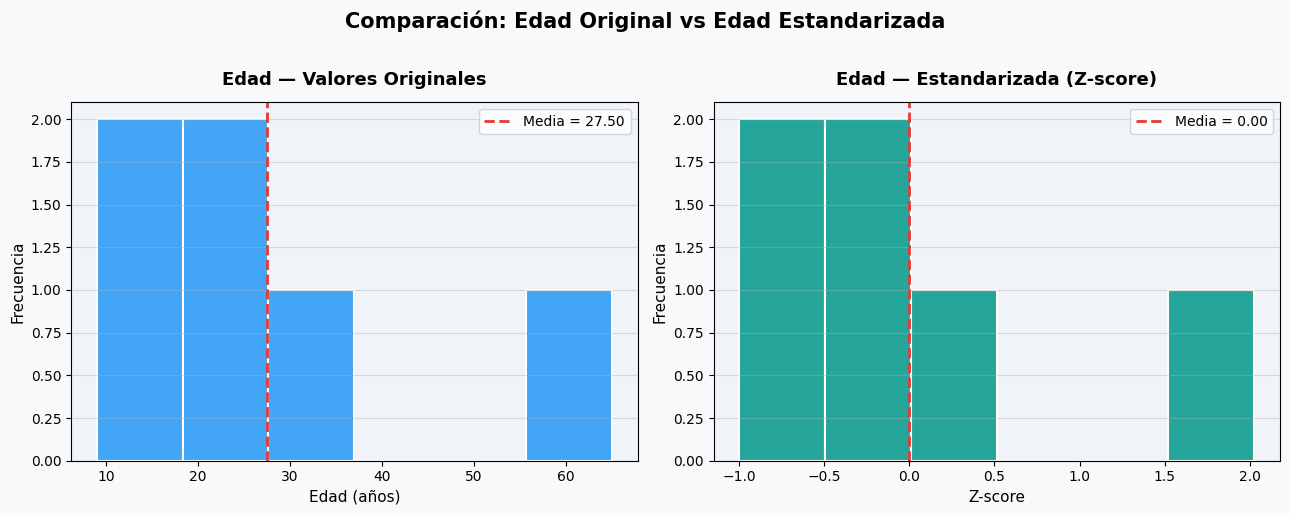

Interpretación: La forma de la distribución NO cambia con la estandarización,
solo cambia la escala del eje X. La distribución se centra en 0.


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#f8f9fa')

colores = ['#42A5F5', '#26A69A']

# ── Gráfico 1: Edad original ──
axes[0].hist(dfOriginal['edad'], bins=6, color=colores[0], edgecolor='white', linewidth=1.5)
axes[0].axvline(dfOriginal['edad'].mean(), color='#e53935', linestyle='--', linewidth=2,
                label=f"Media = {dfOriginal['edad'].mean():.2f}")
axes[0].set_title('Edad — Valores Originales', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Edad (años)', fontsize=11)
axes[0].set_ylabel('Frecuencia', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].set_facecolor('#f0f4f8')
axes[0].grid(axis='y', alpha=0.4)

# ── Gráfico 2: Edad estandarizada ──
axes[1].hist(edad_estandarizada, bins=6, color=colores[1], edgecolor='white', linewidth=1.5)
axes[1].axvline(media_edad, color='#e53935', linestyle='--', linewidth=2,
                label=f'Media = {media_edad:.2f}')
axes[1].set_title('Edad — Estandarizada (Z-score)', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Z-score', fontsize=11)
axes[1].set_ylabel('Frecuencia', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].set_facecolor('#f0f4f8')
axes[1].grid(axis='y', alpha=0.4)

plt.suptitle('Comparación: Edad Original vs Edad Estandarizada',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('Interpretación: La forma de la distribución NO cambia con la estandarización,')
print('solo cambia la escala del eje X. La distribución se centra en 0.')

<div id="conclusiones" style="background-color:#0a0a0a;color:#00ff41;padding:10px 15px;font-family:'Courier New',Courier,monospace;border-left:5px solid #00ff41;border-bottom:1px solid #00ff41;box-shadow:inset 0 0 5px #000000;"><h2 style="margin:0;text-transform:uppercase;">&gt; Conclusiones_ &#9608;</h2></div>

A continuación presento las conclusiones derivadas de la práctica:

1. **Tabla de diseño de transformaciones:** Se identificaron 4 variables del dataset `DATOS-IA.xlsx` y se clasificaron correctamente: `sexo` y `país` como **nominales**, `nivelSatisfaccion` como **ordinal** y `edad` como **numérica continua**. Esta fase de diseño previo es esencial para evitar errores en el pipeline.

2. **Transformaciones categóricas:** Se aplicó `OneHotEncoder` a las variables nominales (`sexo`, `país`), generando **6 columnas binarias** en total (2 para sexo + 4 para país: Brasil, Chile, Ecuador, España). Se aplicó `OrdinalEncoder` a `nivelSatisfaccion` respetando el orden lógico: `no me gusta=0`, `neutral=1`, `me gusta=2`.

3. **Transformaciones numéricas:** Se aplicó `StandardScaler` (estandarización Z-score) a la variable `edad`, ajustando los valores a una escala de media=0 y desviación estándar=1, sin alterar la forma de la distribución.

4. **Estadísticos de la variable edad estandarizada:**
   - **Media ≈ 0** (prácticamente cero, diferencia por precisión de punto flotante)
   - **Desviación estándar ≈ 1** (varianza unitaria)
   
   Esto confirma que el proceso de estandarización fue ejecutado correctamente.

5. **Aprendizaje clave:** El uso combinado de `Pipeline` + `ColumnTransformer` permite construir un preprocesamiento robusto, reproducible y listo para producción, aplicando transformaciones distintas a cada tipo de variable en un solo paso.

---
*Práctica realizada como parte del curso de Inteligencia Artificial — 2026*